# IMPORT

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, kruskal, normaltest, wilcoxon, ttest_rel

load_dotenv()
path = os.getenv('DATA_PATH', r'D:\pandas\source files\project')

# rides.csv

In [2]:
df_r = pd.read_csv(os.path.join(path, 'rides.csv'), sep=',', encoding='UTF-8')

## Предобработка данных

### PEP-8 и типы данных

In [3]:
df_r.columns = df_r.columns.str.lower().str.replace(' ', '_')
df_r.info()

<class 'pandas.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              102255 non-null  int64  
 1   start_date      102255 non-null  str    
 2   end_date        102255 non-null  str    
 3   start_location  102255 non-null  str    
 4   start_district  102255 non-null  str    
 5   end_location    102255 non-null  str    
 6   end_district    102255 non-null  str    
 7   distance        101022 non-null  float64
 8   promo           102255 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 7.0 MB


In [4]:
df_r['start_date'] = pd.to_datetime(df_r['start_date'])
df_r['end_date'] = pd.to_datetime(df_r['end_date'])

### Дубликаты

#### Явные дубликаты

In [5]:
df_r.duplicated().sum()

np.int64(4883)

In [6]:
df_r.duplicated().mean()

np.float64(0.047753166104346975)

In [7]:
dups = df_r[df_r.duplicated(keep=False)]

In [8]:
dups.sort_values('id')

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
16,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
17,100356,2023-04-22 09:44:41,2023-04-22 10:23:10,Энтузиастов,Центральный,Сиреневая,Юго-Восточный,4715.0,0
44,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
45,100383,2023-04-22 10:33:56,2023-04-22 10:58:41,Ломоносова,октябрьский,ул. матросова,Центральный,3907.0,0
81,100419,2023-04-22 11:31:18,2023-04-22 12:03:19,Цветочная,северо-западный,Коммунальная,Юго-Восточный,4801.0,0
...,...,...,...,...,...,...,...,...,...
102181,197640,2023-07-31 21:43:19,2023-07-31 21:58:08,Кирова,Ленинский,Коммунальная,Юго-Восточный,2809.0,0
102183,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102184,197642,2023-07-31 21:44:24,2023-07-31 22:13:12,Восточная,октябрьский,Спортивная,октябрьский,2696.0,0
102204,197662,2023-07-31 21:57:30,2023-07-31 22:26:37,Дорожная,Юго-Восточный,Сиреневая,Юго-Восточный,3700.0,0


In [9]:
df_r[df_r.duplicated(keep=False)].shape

(9766, 9)

видим что строки сдвоены, 4883 дубликатов, 9766 наблюдений

In [10]:
df_r.drop_duplicates()  # избавились от явных дубликатов, приступим к неявным

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,Озерная,Юго-Восточный,Первомайская,Северо-Западный,3302.0,0
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,Мичурина,Ленинский,Садовая,Заречный,4992.0,0
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,Лермонтова,ленинский,Куйбышева,Центральный,2781.0,0
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,Рябиновая,Северо-Западный,Энергетиков,Юго-Восточный,6466.0,0


#### Неявные дубликаты

In [11]:
df_r['start_location'].unique()

<StringArray>
[         'Шевченко',            'Чехова',         'Буденного',
             'Труда',      'Первомайская',            'Лесная',
      'Пролетарская',          'Комарова',          'Западная',
           'Свободы',
 ...
      'ул юбилейная',          'ул новая',    'Ул. Московская',
      'ул цветочная',        'ул свободы',      'Ул. Северная',
         'ул речная',   'Ул. Энтузиастов',     'Ул. Матросова',
 'Ул. Комсомольская']
Length: 463, dtype: str

Если изучить то можно понять что тут записано 3 версии каждой из улиц, например: Буденного буденного ул.буденного

In [12]:
def clean_loc(col):
    return (
        col.str.strip()
        .str.lower()
        .str.replace(r'^ул\.?\s*', '', regex=True)  
        .str.replace(r'\s+', '', regex=True)
    )

df_r['start_location'] = clean_loc(df_r['start_location'])
df_r['end_location'] = clean_loc(df_r['end_location'])

In [13]:
def clean_district(col):
    return(
        col.str.strip()
        .str.lower()
        .str.replace(r'северозападный', 'северо-западный', regex=True)
        .str.replace(r'северо западный', 'северо-западный', regex=True)
    )

df_r['end_district'] = clean_district(df_r['end_district'])
df_r['start_district'] = clean_district(df_r['start_district'])

### Выбросы

In [14]:
df_r.info()

<class 'pandas.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              102255 non-null  int64         
 1   start_date      102255 non-null  datetime64[us]
 2   end_date        101676 non-null  datetime64[us]
 3   start_location  102255 non-null  str           
 4   start_district  102255 non-null  str           
 5   end_location    102255 non-null  str           
 6   end_district    102255 non-null  str           
 7   distance        101022 non-null  float64       
 8   promo           102255 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(4)
memory usage: 7.0 MB


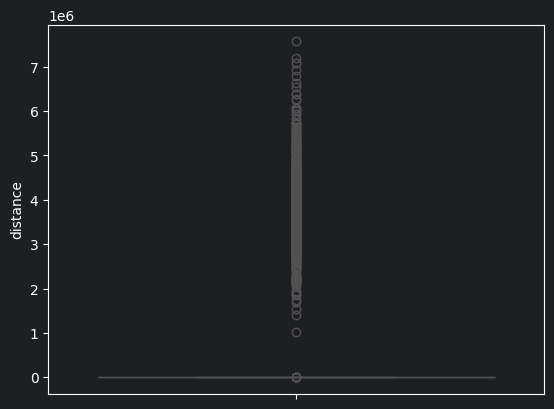

In [15]:
sns.boxplot(df_r, y='distance')
plt.show()

In [16]:
print(df_r['distance'].max())

7569789.0


In [17]:
max_dist = df_r['distance'].max()
row = df_r.loc[df_r['distance'] == max_dist]
print(
    row
)  # смотрим почему проехал больше всех. В целом за 42 минуты можно проехать 7569 метров

           id          start_date            end_date start_location  \
78664  175247 2023-07-10 09:57:49 2023-07-10 10:39:40         лесная   

      start_district end_location     end_district   distance  promo  
78664  юго-восточный    березовая  северо-западный  7569789.0      1  


### Пропуски и выбросы


In [18]:
df_r.isna().sum()

id                   0
start_date           0
end_date           579
start_location       0
start_district       0
end_location         0
end_district         0
distance          1233
promo                0
dtype: int64

In [19]:
# Можно подметить, что мы имеем мало строк с пропуском конечной даты относительно кол-ва поездок
# Для предположения сколько ехал человек (end_date - start_date) нужно знать среднюю скорость между точками
# Но скорость не является постоянной в отличие от дистанции, ведь зависит от множества факторов
# Опытность пилота, характера вождения пилота, его целей на поездку
# Также зависит от выбранного участка (его условий и нагруженности)
# И естественно зависит от погоды.
# Исходя из вышесказанного, можно подметить, что предусмотреть оптимальную замену пропуску не является возможным с нашим уровнем погружения.
df_r.dropna(subset=['end_date'], inplace=True)

In [20]:
# Попытаемся проанализировать возможные способы работы с пропусками для дистанции.
stats = (
    df_r.groupby(['start_location', 'end_location'])['distance']
    .agg(['min', 'max', 'median', 'mean', 'count'])
    .round(2)
)
stats['range'] = stats['max'] - stats['min']
stats = stats.sort_values('range', ascending=False)

print("Группы с наибольшим разрывом (min-max):")
print(stats.head(10))
# Уже заметно, что я обнаружил новый выброс

Группы с наибольшим разрывом (min-max):
                                   min        max  median       mean  count  \
start_location end_location                                                   
лесная         березовая        2896.0  7569789.0  4976.0  477831.25     16   
садовая        полевая             8.0  7204885.0  5442.5  405277.72     18   
рабочая        чкалова          3564.0  7073888.0  5209.0  888589.88     16   
московская     чкалова          3567.0  6914067.0  5679.0  633480.91     11   
лесная         новая            3125.0  6784244.0  5111.0  620914.45     11   
полевая        пионерская       1527.0  6627165.0  4944.5  225466.27     30   
пионерская     партизанская        3.0  6543723.0  4915.0  368048.89     18   
сиреневая      московская       4131.0  6377036.0  4936.0  854506.60     15   
красная        красноармейская     6.0  6263485.0  5180.0  630531.20     10   
мичурина       шоссейная        2964.0  6258726.0  5273.0  265647.58     24   

           

In [21]:
print(
    len(stats[stats['count'] < 50]), len(stats[stats['count'] >= 50])
)  # Невозможно адекватно определить выбросы.

8251 26


In [22]:
# Попытаемся проанализировать возможные способы работы с пропусками для дистанции, возьмем по районам.
stats_district = (
    df_r.groupby(['start_district', 'end_district'])['distance']
    .agg(['min', 'max', 'median', 'count'])
    .round(2)
)
stats_district['range'] = stats_district['max'] - stats_district['min']


print("Группы с наибольшим разрывом (min-max) по районам:")
print(stats_district)

Группы с наибольшим разрывом (min-max) по районам:
                                 min        max  median  count      range
start_district  end_district                                             
заречный        заречный         2.0  3878765.0  3005.0    937  3878763.0
                ленинский        3.0  7204885.0  5031.0   1509  7204882.0
                октябрьский      2.0  3491754.0  3513.0   1303  3491752.0
                северо-западный  3.0  5067538.0  4059.5   1510  5067535.0
                центральный      1.0  5648909.0  4011.0   2499  5648908.0
                юго-восточный    3.0  4527684.0  4011.5   1884  4527681.0
ленинский       заречный         2.0  6627165.0  5065.5   1540  6627163.0
                ленинский        2.0  4100201.0  3054.0   2586  4100199.0
                октябрьский      2.0  5165855.0  4053.0   2187  5165853.0
                северо-западный  2.0  4477585.0  3547.5   2596  4477583.0
                центральный      2.0  4868318.0  3519.5   405

In [23]:
print(
    len(stats_district[stats_district['count'] < 50]),
    len(stats_district[stats_district['count'] >= 50]),
)  # Для таких групп, уже возможно выделение выбросов.

0 36


In [24]:
def fill_outliers_and_missing(group_cols, target_col):
    df_clean = df_r.copy()
    for name, group in df_r.groupby(group_cols):
        data = group[target_col].dropna()
        if len(data) > 0:
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            idx = group.index
            df_clean.loc[idx, target_col] = df_clean.loc[idx, target_col].fillna(
                data[(data >= lower) & (data <= upper)].median()
            )
            df_clean.loc[idx, target_col] = df_clean.loc[idx, target_col].clip(
                lower, upper
            )
    return df_clean


df_r = fill_outliers_and_missing(
    ['start_district', 'end_district'], 'distance'
)  # Убираем выбросы по 1.5 * iqr и пропуски.

In [25]:
df_r.isna().sum()

id                0
start_date        0
end_date          0
start_location    0
start_district    0
end_location      0
end_district      0
distance          0
promo             0
dtype: int64

In [26]:
# Проверим
stats_district = (
    df_r.groupby(['start_district', 'end_district'])['distance']
    .agg(['min', 'max', 'median', 'count'])
    .round(2)
)
stats_district['range'] = stats_district['max'] - stats_district['min']


print(stats_district)  # Теперь лучше :)

                                     min      max  median  count   range
start_district  end_district                                            
заречный        заречный         1294.00  4670.00  3018.0    954  3376.0
                ленинский        1476.00  8420.00  5049.0   1530  6944.0
                октябрьский      1451.00  5563.00  3525.5   1320  4112.0
                северо-западный  1518.38  6609.38  4070.5   1524  5091.0
                центральный      1436.75  6610.75  4025.5   2530  5174.0
                юго-восточный    1512.50  6532.50  4022.0   1905  5020.0
ленинский       заречный         1716.75  8316.75  5088.0   1563  6600.0
                ленинский        1270.62  4829.62  3065.0   2615  3559.0
                октябрьский      1609.75  6495.75  4067.5   2210  4886.0
                северо-западный  1339.62  5676.62  3561.0   2624  4337.0
                центральный      1299.00  5771.00  3531.0   4098  4472.0
                юго-восточный    1381.62  6630.62  

## Добавление итоговой_стоимости

In [27]:
def get_rate(hour, weekday):
    is_weekend = weekday >= 5

    if 1 < hour < 6:
        return 3
    elif 5 < hour < 10:
        return 4
    elif 9 < hour < 16:
        return 6 if is_weekend else 5
    elif 15 < hour < 22:
        return 7 if is_weekend else 6
    elif hour > 21 or hour < 1:
        return 6 if is_weekend else 5
    else:
        return 0

def calc_cost(row):
    distance = row['distance']
    start = row['start_date']
    end = row['end_date']
    hour = start.hour
    weekday = start.weekday()
    duration = (end - start).total_seconds() / 60
    promo = row['promo']

    rate = get_rate(hour, weekday)

    base = 0 if promo else 30
    return base + duration * rate
            

df_r['total_cost'] = df_r.apply(calc_cost, axis=1)

## Добавление скорости 

In [28]:
df_r['duration'] = df_r['end_date'] - df_r['start_date']

In [29]:
df_r['distance'].value_counts()

distance
1277.500    187
1392.250    165
1489.750    152
1337.125    144
1328.500    139
           ... 
1449.000      1
8117.000      1
1496.000      1
1538.000      1
1341.000      1
Name: count, Length: 5780, dtype: int64

In [30]:
df_r['duration'].value_counts()

duration
0 days 00:22:37    111
0 days 00:20:23    109
0 days 00:23:55    106
0 days 00:21:37    106
0 days 00:20:22    105
                  ... 
0 days 01:10:22      1
0 days 00:05:36      1
0 days 01:02:15      1
0 days 01:12:20      1
0 days 01:08:35      1
Name: count, Length: 3809, dtype: int64

In [31]:
seconds = df_r['duration'].dt.total_seconds() 
speed = round(df_r['distance'] / seconds, 3) 
df_r['speed'] = speed
# добавляем фактор speed, где скорость измеряется в метрах на секунду

In [32]:
df_r.head()

,id,start_date,end_date,start_location,start_district,end_location,end_district,distance,promo,total_cost,duration,speed
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,124.800000,0 days 00:23:42,2.861
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,143.666667,0 days 00:28:25,2.648
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,183.266667,0 days 00:38:19,1.966
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,157.266667,0 days 00:31:49,2.033
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,152.666667,0 days 00:30:40,2.190


In [33]:
diff = (df_r['speed'] * df_r['duration'].dt.total_seconds() - df_r['distance']).abs()
diff.describe() # значит что все почти сходится, разница в 2 метра - ничего страшного

count    101676.000000
mean          0.397556
std           0.287758
min           0.000000
25%           0.176000
50%           0.350000
75%           0.560000
max           2.371000
dtype: float64

# weather.csv

In [34]:
df_w = pd.read_csv(os.path.join(path, 'weather.csv'), sep=',', encoding='UTF-8')

## Предобработка данных

In [35]:
df_w.info()

<class 'pandas.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Datetime             3672 non-null   str  
 1   Temperature          3618 non-null   str  
 2   Precipitation Total  3643 non-null   str  
 3   Wind Gust            3673 non-null   str  
 4   Wind Speed           3657 non-null   str  
 5   Cloud Cover Total    3653 non-null   str  
 6   Sunshine Duration    3661 non-null   str  
dtypes: str(7)
memory usage: 201.0 KB


### PEP-8 и типы данных

In [36]:
df_w.columns = df_w.columns.str.lower().str.replace(' ', '_')

In [37]:
df_w.info()  # ,°C,mm,km/h,km/h,%,min

<class 'pandas.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   datetime             3672 non-null   str  
 1   temperature          3618 non-null   str  
 2   precipitation_total  3643 non-null   str  
 3   wind_gust            3673 non-null   str  
 4   wind_speed           3657 non-null   str  
 5   cloud_cover_total    3653 non-null   str  
 6   sunshine_duration    3661 non-null   str  
dtypes: str(7)
memory usage: 201.0 KB


In [38]:
df_w = df_w.drop(0)
df_w.head(5)  # строка с индексом 0 имеет записи об еденицах измерения, нужно её удалить

,datetime,temperature,precipitation_total,wind_gust,wind_speed,cloud_cover_total,sunshine_duration
1,2023-04-01T00:00:00,8.740245,0.1,48.6,21.638964,90,0
2,2023-04-01T01:00:00,9.040245,0.2,55.44,22.493519,74,0
3,2023-04-01T02:00:00,8.880245,0.3,55.8,22.26477,72,0
4,2023-04-01T03:00:00,8.690246,0.3,55.44,21.94524,77,0
5,2023-04-01T04:00:00,8.630245,0.3,48.96,22.42427,78,0


In [39]:
df_w['datetime'].unique()  # нам нужно поменять формат на datetime

<StringArray>
['2023-04-01T00:00:00', '2023-04-01T01:00:00', '2023-04-01T02:00:00',
 '2023-04-01T03:00:00', '2023-04-01T04:00:00', '2023-04-01T05:00:00',
 '2023-04-01T06:00:00', '2023-04-01T07:00:00', '2023-04-01T08:00:00',
 '2023-04-01T09:00:00',
 ...
 '2023-08-31T14:00:00', '2023-08-31T15:00:00', '2023-08-31T16:00:00',
 '2023-08-31T17:00:00', '2023-08-31T18:00:00', '2023-08-31T19:00:00',
 '2023-08-31T20:00:00', '2023-08-31T21:00:00', '2023-08-31T22:00:00',
 '2023-08-31T23:00:00']
Length: 3672, dtype: str

#### приведение типов данных

In [40]:
df_w['datetime'] = pd.to_datetime(df_w['datetime'])
df_w['temperature'] = df_w['temperature'].astype(
    float
)  # температура у нас не string а float должна быть
df_w['precipitation_total'] = df_w['precipitation_total'].astype(
    float
)  # тоже тип float потому что наблюдения: 1.9 (пример)
df_w['wind_gust'] = df_w['wind_gust'].astype(float)
df_w['wind_speed'] = df_w['wind_speed'].astype(float)
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].astype(
    float
)  # на первый взгляд целочисленные, но там еще есть десятичные
df_w['sunshine_duration'] = df_w['sunshine_duration'].astype(
    float
)  # данные в вещественном формате

### Дубликаты

#### Явные дубликаты

In [41]:
df_w.duplicated().sum()  # явных дубликатов не обнаружено

np.int64(0)

#### Неявные дубликаты

In [42]:
df_w['temperature'].unique()

array([ 8.740245,  9.040245,  8.880245, ..., 14.290245, 15.410245,
       19.980246], shape=(1964,))

In [43]:
# Т. к. мы имеем дату, то ввиду отсутствия явных дубликатов и категориальных можно сделать вывод, что неявные дубликаты отсутствуют.

### Выбросы

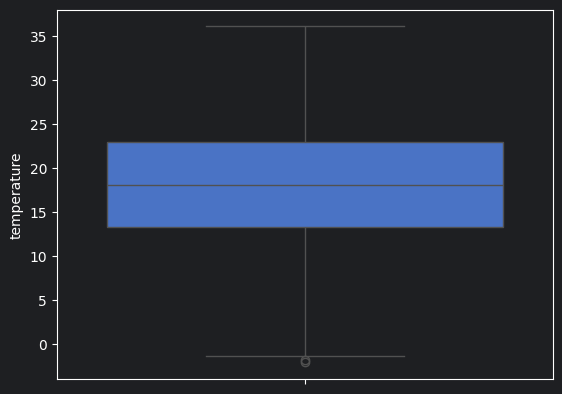

In [44]:
sns.boxplot(df_w, y='temperature')
plt.show()

### Пропуски

In [45]:
df_w.isna().sum()

datetime                0
temperature            55
precipitation_total    30
wind_gust               0
wind_speed             16
cloud_cover_total      20
sunshine_duration      12
dtype: int64

In [46]:
def missing_all(col):
    df_w.isna().sum()
    plt.figure(figsize=(15, 5))
    missing_mask = df_w[col].isnull()
    plt.scatter(
        df_w.loc[~missing_mask, 'datetime'],
        df_w.loc[~missing_mask, col],
        c='blue',
        s=10,
        alpha=0.5,
        label='Есть данные',
    )
    plt.scatter(
        df_w.loc[missing_mask, 'datetime'],
        [0] * missing_mask.sum(),
        c='red',
        s=20,
        alpha=0.7,
        label='Пропуски',
        marker='x',
    )
    plt.title('Пропуски в столбце temperature', fontsize=14)
    plt.xlabel('Дата и время', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

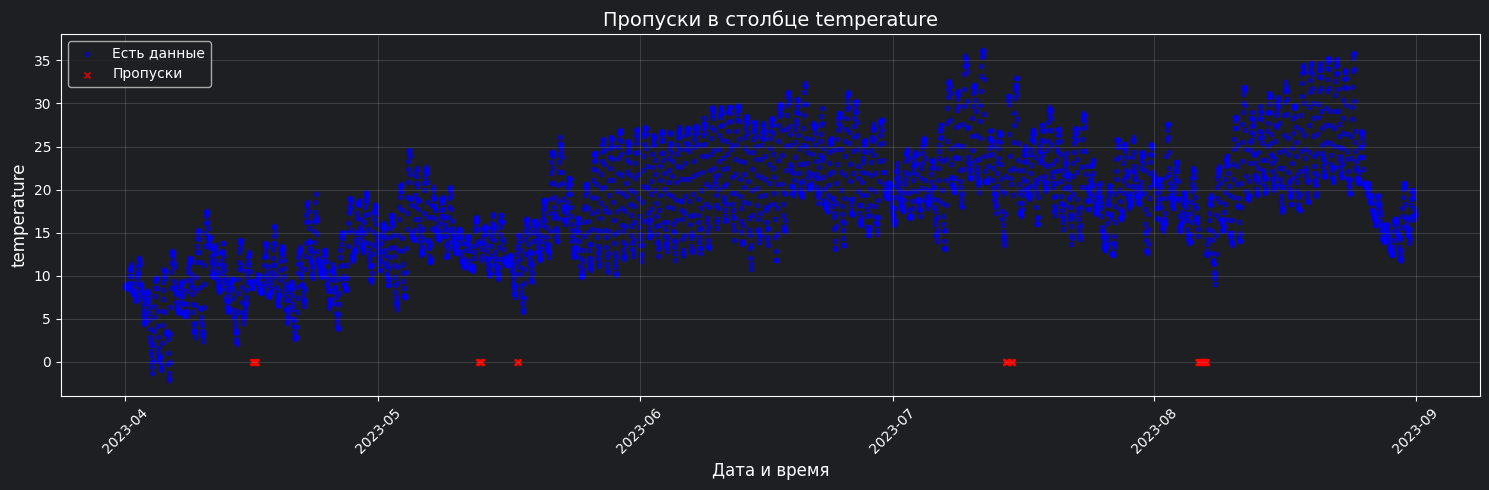

In [47]:
# Температура
missing_all('temperature')
# Видно, что имеются группы выбросов. Далее детально рассматриваем каждую.

In [48]:
def missing_groups(column):
    missing = df_w[column].isnull()
    groups = []
    flag = None

    for i, is_miss in enumerate(missing):
        if is_miss and flag is None:
            flag = i
        elif not is_miss and flag is not None:
            groups.append((flag, i - 1))
            flag = None
    if flag is not None:
        groups.append((flag, len(missing) - 1))

    pad = len(groups)
    rows = (len(groups) + 1) // 2
    fig, axes = plt.subplots(rows, min(2, len(groups)), figsize=(15, 4 * rows))
    axes = [axes] if len(groups) == 1 else axes.flatten()

    for i, (s, e) in enumerate(groups):
        start_idx = max(0, s - pad)
        end_idx = min(len(df_w), e + pad)
        subset = df_w.iloc[start_idx:end_idx]

        axes[i].plot(
            subset['datetime'][subset[column].notna()],
            subset[column].dropna(),
            'o-',
            color='blue',
            markersize=3,
        )
        axes[i].axvspan(
            subset['datetime'].iloc[s - start_idx],
            subset['datetime'].iloc[e - start_idx],
            alpha=0.2,
            color='red',
        )
        axes[i].set_title(f'Группа {i+1}: {e-s+1} пропусков')
        axes[i].set_xlabel('Дата')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

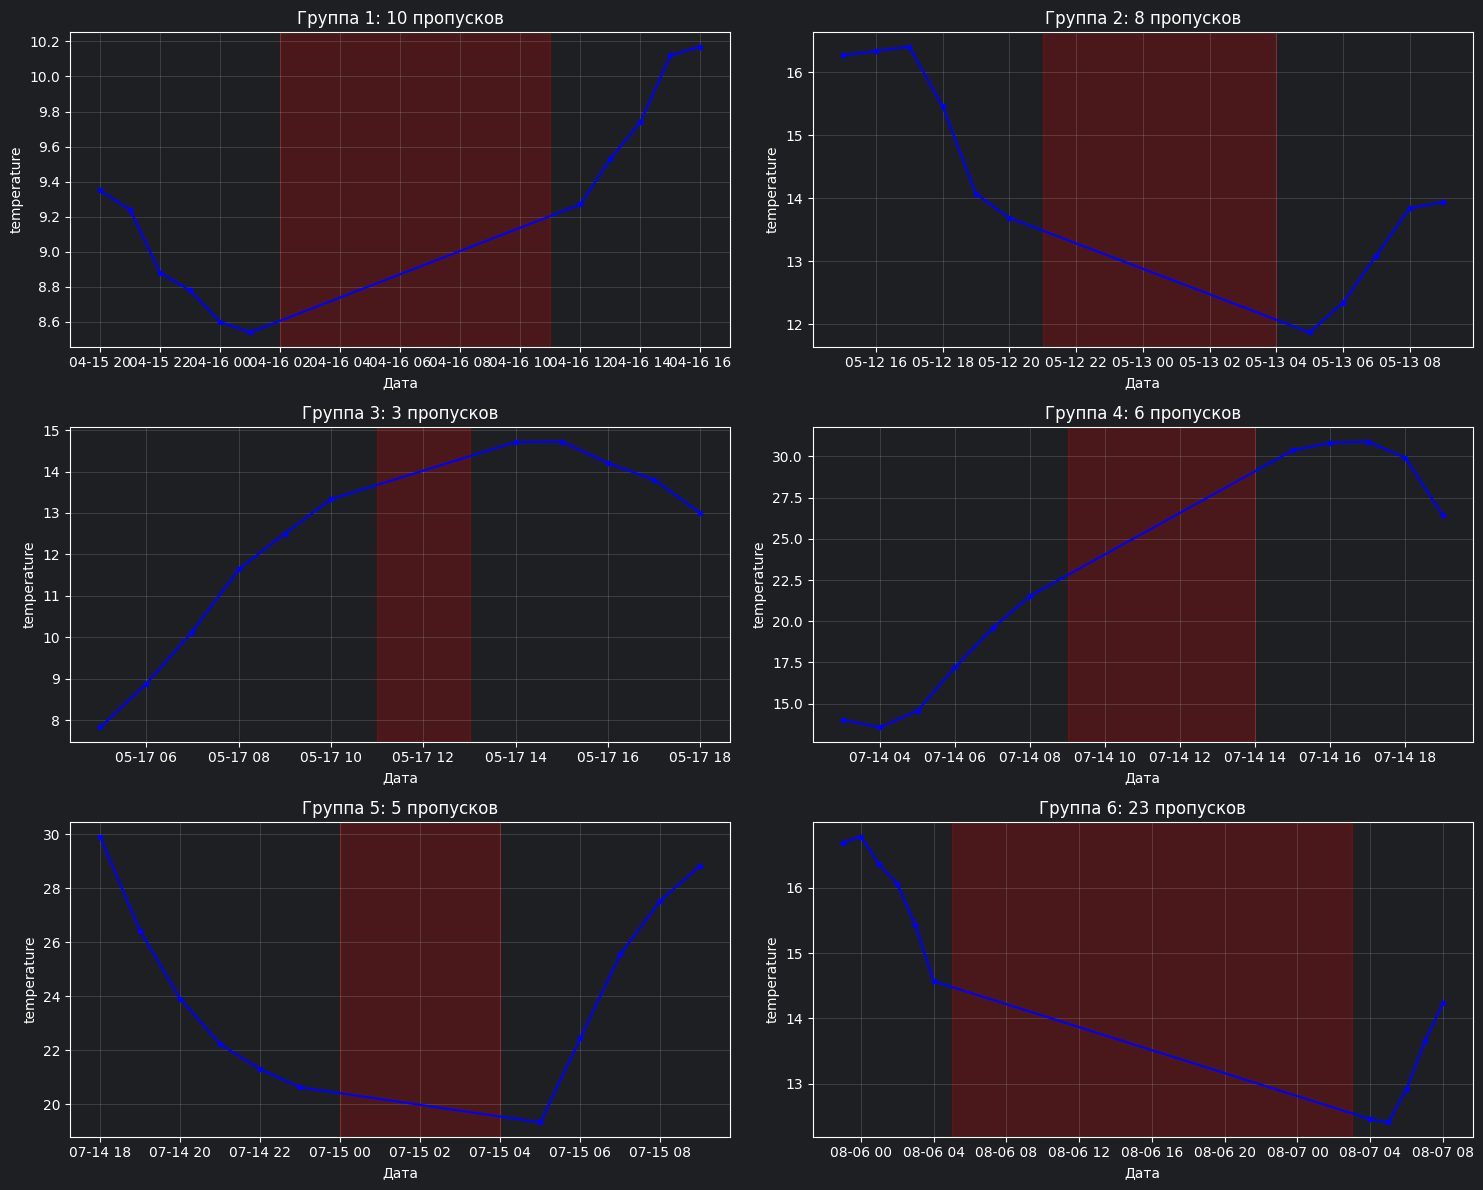

In [49]:
missing_groups(
    'temperature'
)  # Видно трендовость пропусков по группам, значит заполнение интерполяцией будет оптимально.

In [50]:
df_w['temperature'] = df_w['temperature'].interpolate(
    method='linear', limit_direction='both'
)

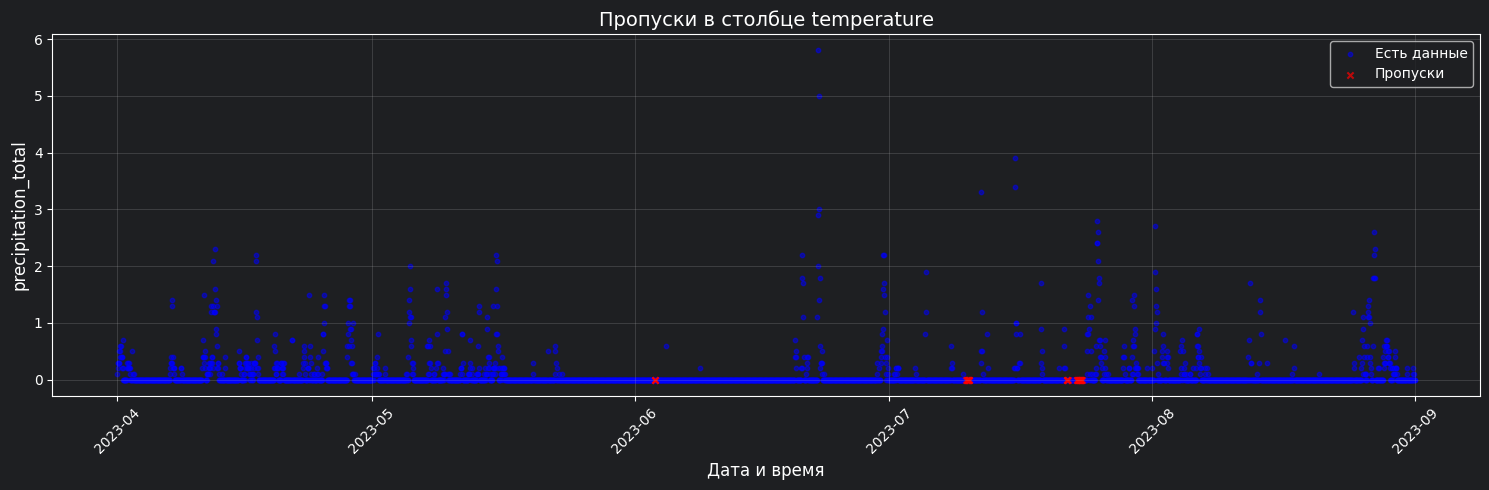

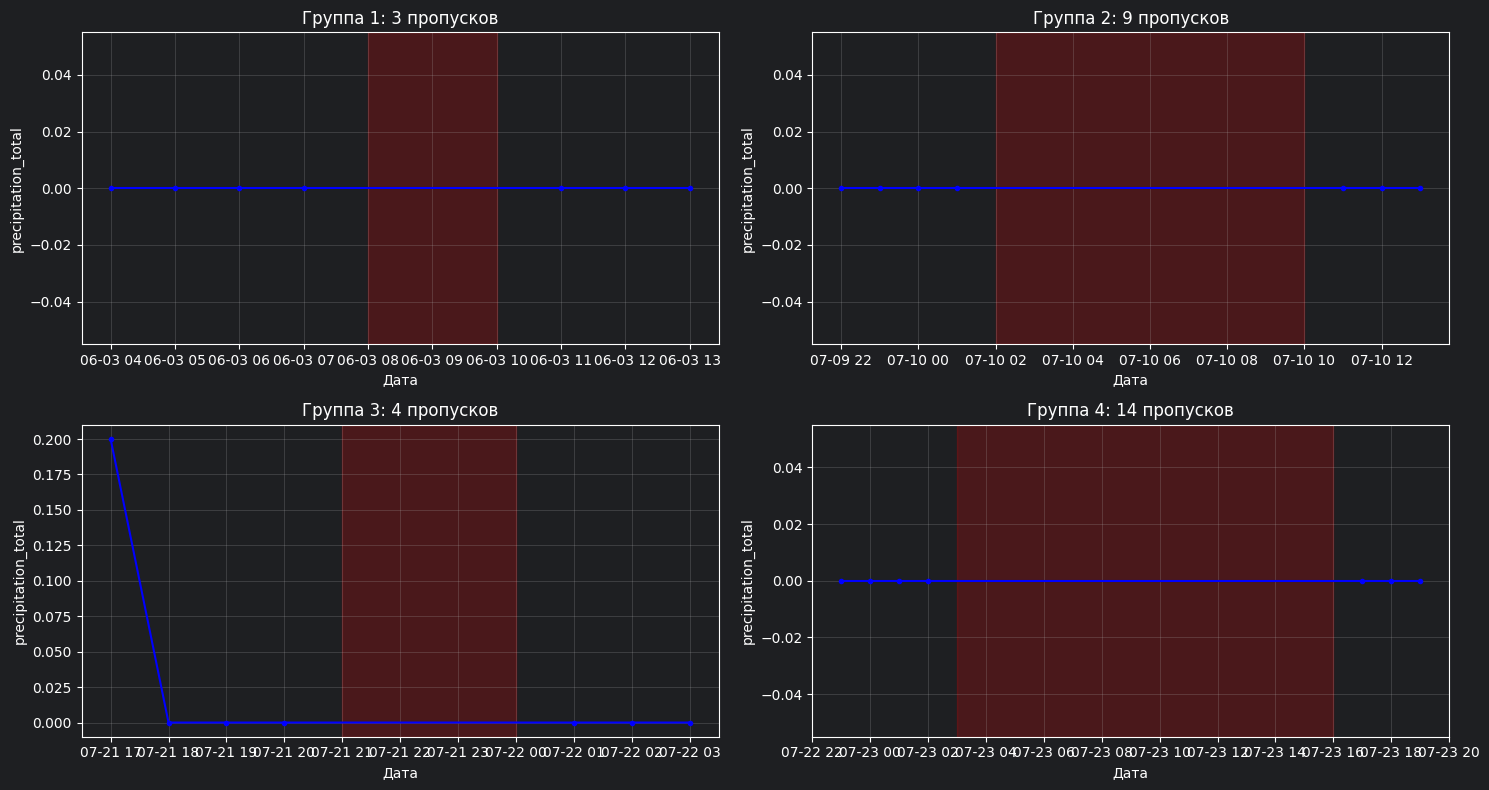

In [51]:
missing_all('precipitation_total')
missing_groups('precipitation_total')
# Аналогично температуре.

In [52]:
df_w['precipitation_total'] = df_w['precipitation_total'].interpolate(
    method='linear', limit_direction='both'
)

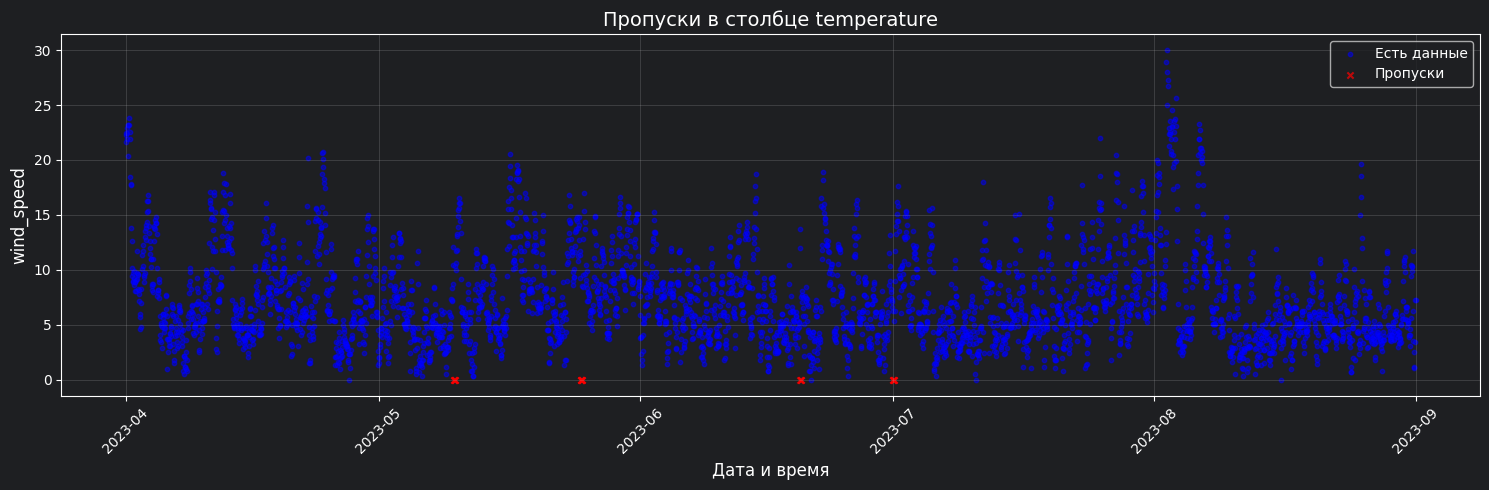

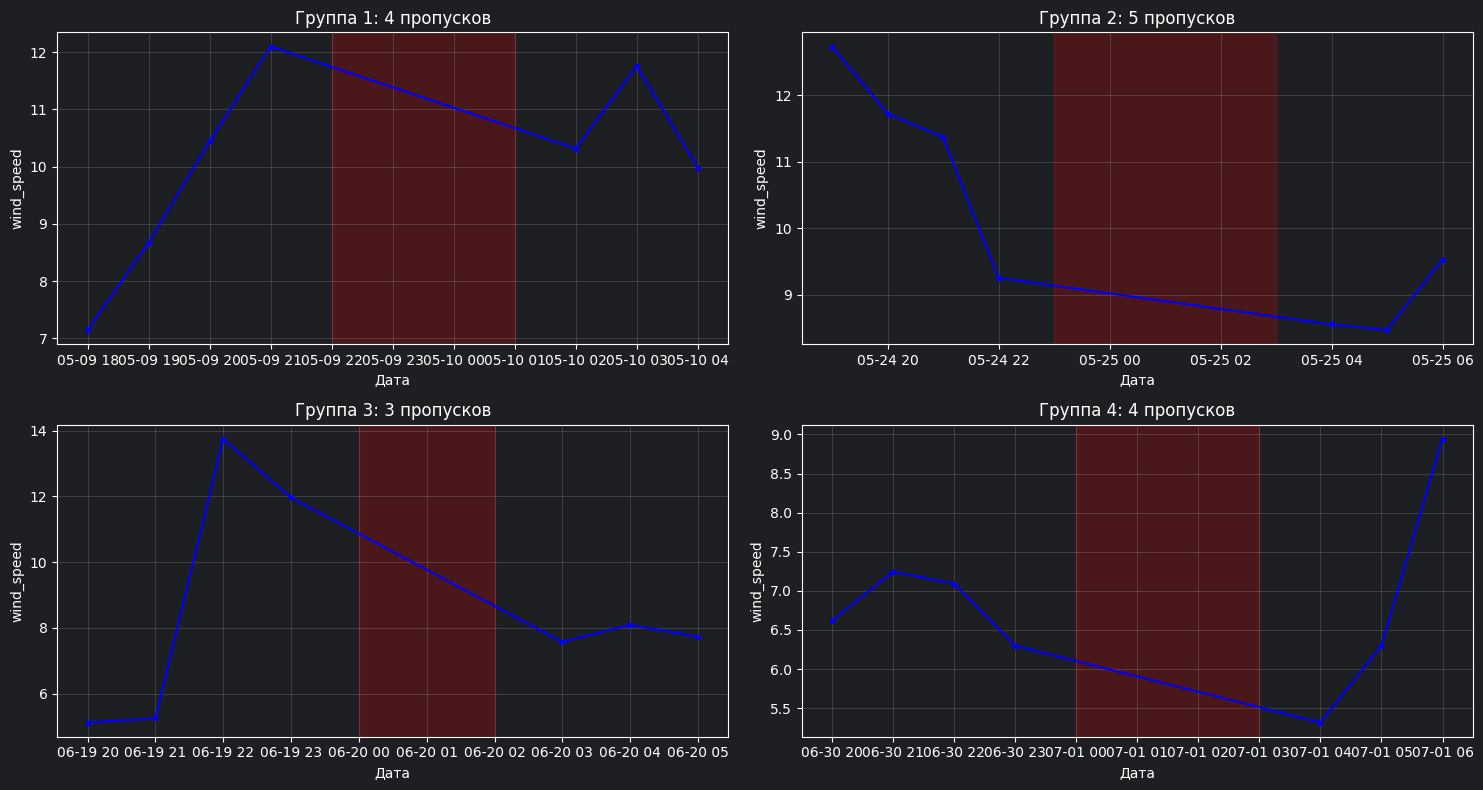

In [53]:
missing_all('wind_speed')
missing_groups('wind_speed')
# Аналогично предыдущим

In [54]:
df_w['wind_speed'] = df_w['wind_speed'].interpolate(
    method='linear', limit_direction='both'
)

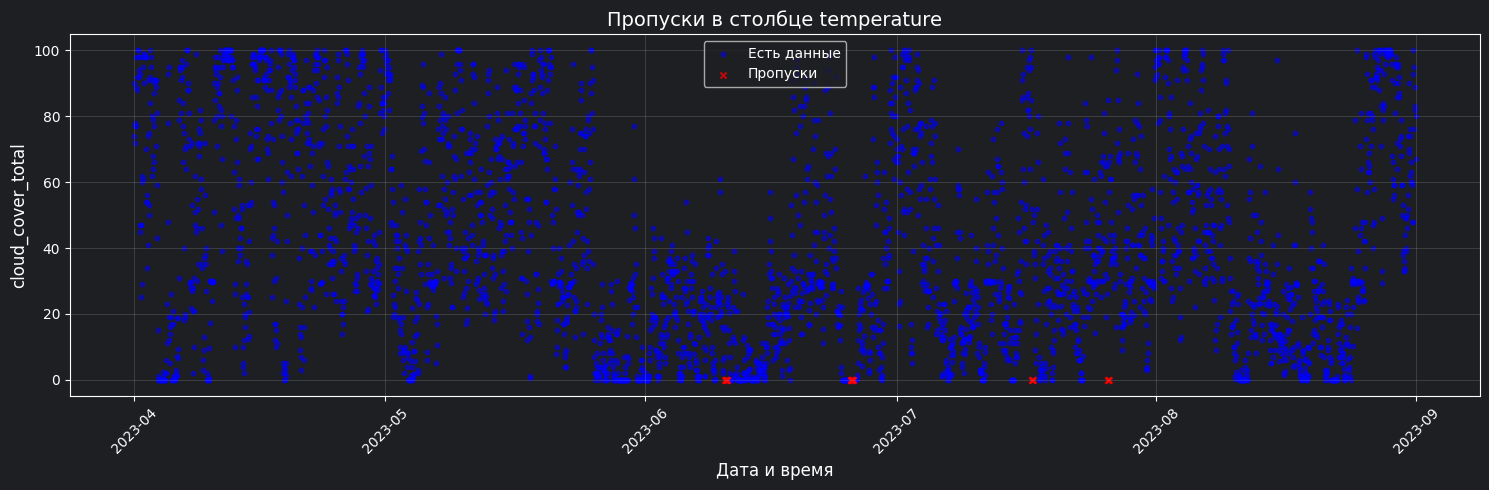

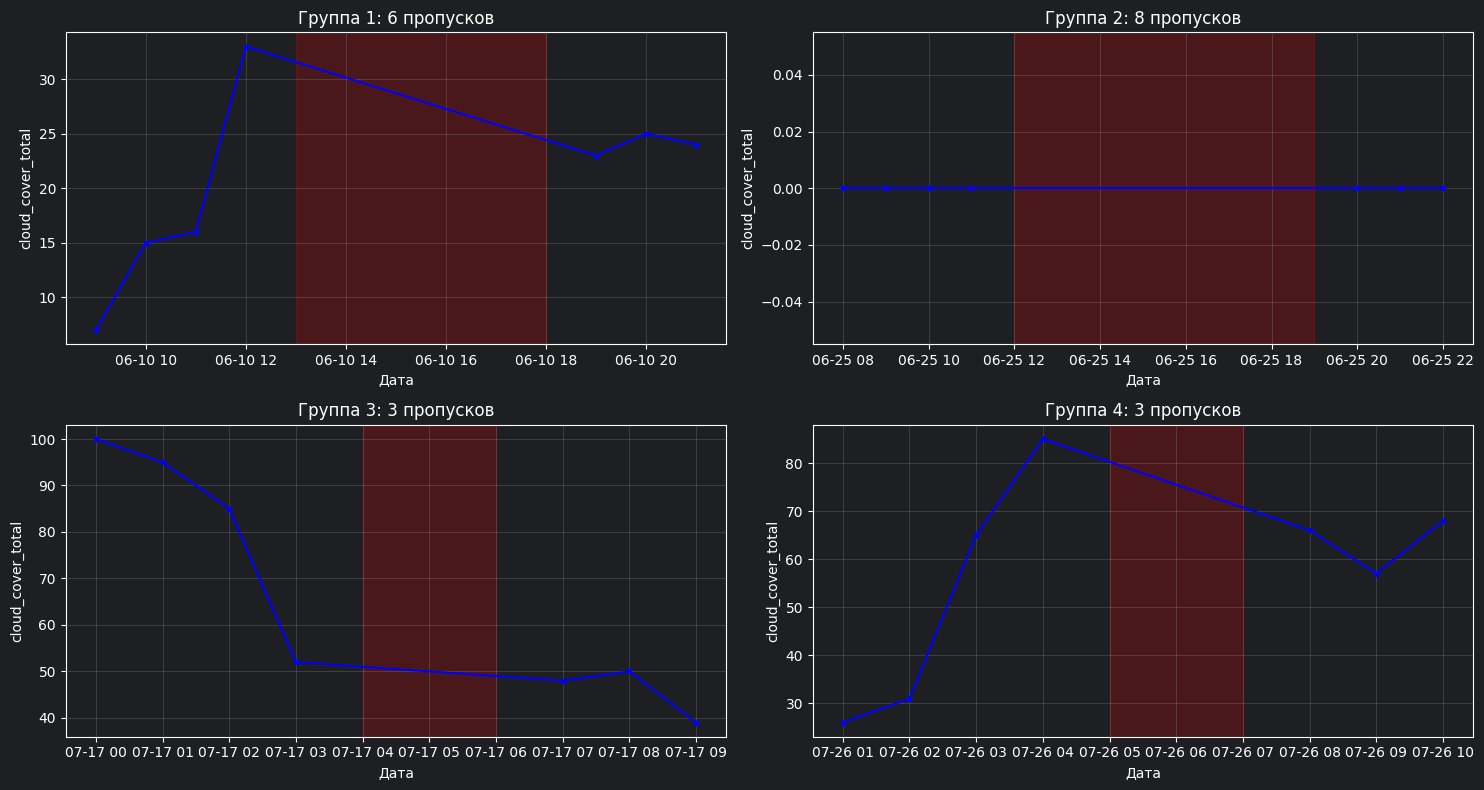

In [55]:
missing_all('cloud_cover_total')
missing_groups('cloud_cover_total')
# Аналогично предыдущим

In [56]:
df_w['cloud_cover_total'] = df_w['cloud_cover_total'].interpolate(
    method='linear', limit_direction='both'
)

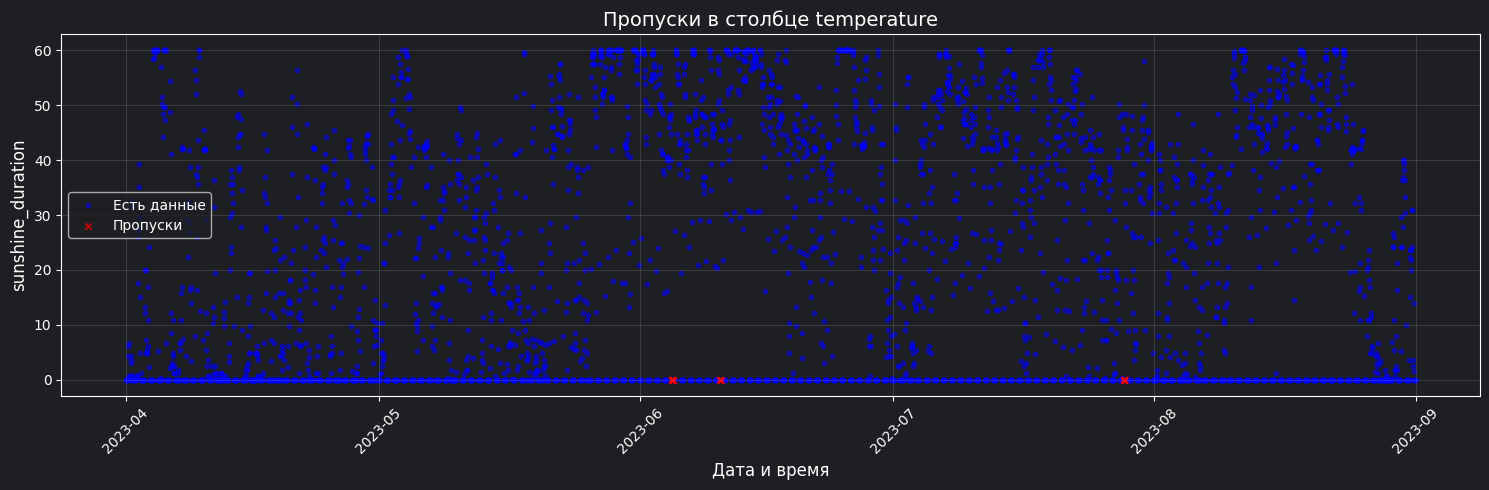

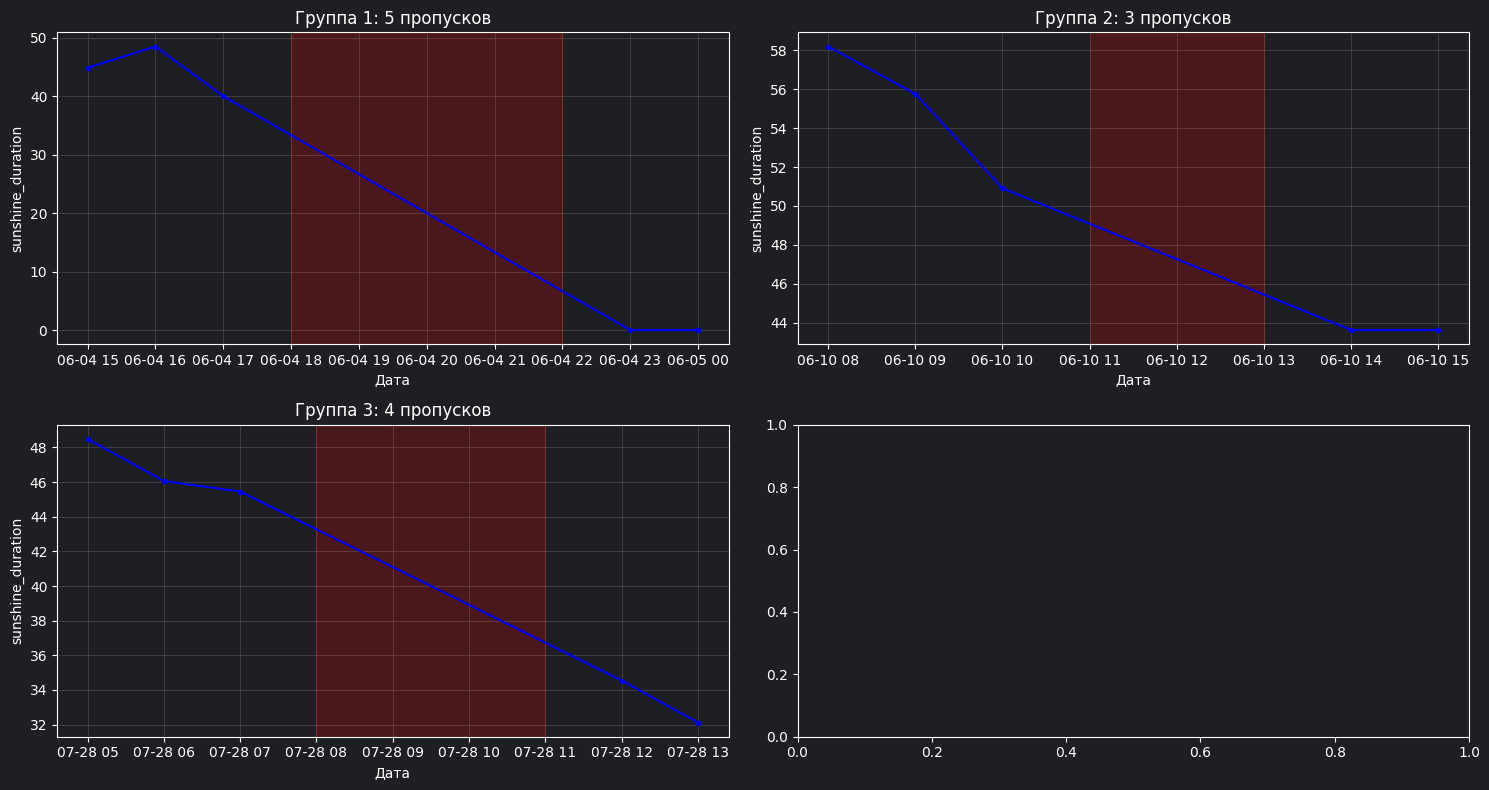

In [57]:
missing_all('sunshine_duration')
missing_groups('sunshine_duration')
# Аналогично предыдущим

In [58]:
df_w['sunshine_duration'] = df_w['sunshine_duration'].interpolate(
    method='linear', limit_direction='both'
)

In [59]:
# Смею предположить, что происходили сбои в сборе определенного типа дынных. Они были относительно кратковременны.

In [60]:
df_w.isna().sum()

datetime               0
temperature            0
precipitation_total    0
wind_gust              0
wind_speed             0
cloud_cover_total      0
sunshine_duration      0
dtype: int64

# Гипотезы

## Спрос в дождливые дни

In [61]:
# мы должны взять похожие дни, один день дождливый, другой день обычный (например, понедельник и вторник дождливый)
# возьмем некоторое количество пар, для более гарантированного исследования
# думаю, что лучше написать функцию для того чтобы находить дождливые дни, одного дня недели

In [62]:
def search_rain_day(df_w, weekdays):
    df_daily = df_w.groupby(df_w['datetime'].dt.floor('D')).agg({
        'precipitation_total': 'sum'
    }).reset_index()
    
    df_daily['weekday'] = df_daily['datetime'].dt.weekday
    
    pairs = []

    for weekday in weekdays:
        rainy_days = df_daily[
            (df_daily['weekday'].isin(weekdays)) & 
            (df_daily['precipitation_total'] > 0)
        ]
        
        non_rainy_days = df_daily[
            (df_daily['weekday'].isin(weekdays)) & 
            (df_daily['precipitation_total'] == 0)
        ]

        for rain_day in rainy_days.itertuples():
            if not non_rainy_days.empty:
                non_rain_day = non_rainy_days.iloc[0]
                pairs.append({
                    'rainy_day': rain_day.datetime.date(),  
                    'non_rain_day': non_rain_day.datetime.date(),  
                })
                non_rainy_days = non_rainy_days.drop(non_rain_day.name)

    return pairs


def compare_demand(rides_df, rain_pairs): # соеденяем в датафрейм наблюдений из rides.csv
    demand_comparison = []

    for pair in rain_pairs:
        rainy_day = pair['rainy_day']
        non_rain_day = pair['non_rain_day']
        
        rainy_demand = rides_df[rides_df['start_date'].dt.date == rainy_day].shape[0]
        non_rainy_demand = rides_df[rides_df['start_date'].dt.date == non_rain_day].shape[0]
        
        demand_comparison.append({
            'rainy_day': rainy_day,
            'non_rain_day': non_rain_day,
            'rainy_demand': rainy_demand,
            'non_rainy_demand': non_rainy_demand,
        })

    return pd.DataFrame(demand_comparison)


def test_normality(df_comparison): # Проверка нормальности, выбор теста, также учитываем что выборки зависимые
    rainy_demand = df_comparison['rainy_demand']
    non_rainy_demand = df_comparison['non_rainy_demand']
    
    stat_rainy, p_rainy = shapiro(rainy_demand)
    stat_non_rainy, p_non_rainy = shapiro(non_rainy_demand)
    
    if p_rainy < 0.05 or p_non_rainy < 0.05:
        stat, p = wilcoxon(rainy_demand, non_rainy_demand)
    else:
        stat, p = ttest_rel(rainy_demand, non_rainy_demand)

    return stat, p


rain_pairs = search_rain_day(df_w, [0, 1, 2, 3, 4])  
df_comparison = compare_demand(df_r, rain_pairs)

stat, p = test_normality(df_comparison)
print(stat, p) 
# p-value < 0.05 соответственно, в будние дни(в выходные p-val=0.0002, если сравнивать отдельно - H1 тоже)
# СТАТИСТИЧЕСКИ ЗНАЧИМО!

4432.5 1.1323915442864866e-07


## Отличие ср.стоимости по районам

In [63]:
# что бы посчитать нам нужно сгруппировать по старту и по концу итоговую стоимость и что то понять, доказать 

In [64]:
df_r.info()

<class 'pandas.DataFrame'>
Index: 101676 entries, 0 to 102254
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype          
---  ------          --------------   -----          
 0   id              101676 non-null  int64          
 1   start_date      101676 non-null  datetime64[us] 
 2   end_date        101676 non-null  datetime64[us] 
 3   start_location  101676 non-null  str            
 4   start_district  101676 non-null  str            
 5   end_location    101676 non-null  str            
 6   end_district    101676 non-null  str            
 7   distance        101676 non-null  float64        
 8   promo           101676 non-null  int64          
 9   total_cost      101676 non-null  float64        
 10  duration        101676 non-null  timedelta64[us]
 11  speed           101676 non-null  float64        
dtypes: datetime64[us](2), float64(3), int64(2), str(4), timedelta64[us](1)
memory usage: 14.1 MB


In [65]:
df_r['start_district'].unique()

<StringArray>
[  'юго-восточный',        'заречный',     'октябрьский',     'центральный',
 'северо-западный',       'ленинский']
Length: 6, dtype: str

In [66]:
def compare_mean_cost(df_r):
    districts = df_r['start_district'].unique().tolist()

    results = []

    for i in range(len(districts)):
        for j in range(i+1, len(districts)):
            a1 = districts[i]
            a2 = districts[j]

            price_1 = df_r[df_r['start_district'] == a1]['total_cost']
            price_2 = df_r[df_r['start_district'] == a2]['total_cost']

            mean_1 = price_1.mean()
            mean_2 = price_2.mean()

            stat, p = mannwhitneyu(price_1, price_2)

            results.append({
                'district_1': a1,
                'district_2': a2,
                'mean_1': mean_1,
                'mean_2': mean_2,
                'p-value': round(p, 4),
                'result': 'H1' if p < 0.05 else 'H0'
            })


    results_df = pd.DataFrame(results)
    print(results_df)

compare_mean_cost(df_r) # видим что у всех райнов, кроме 1 пары отличается стоимость - принимаем H1 - СТАТИСТИЧЕСКИ ЗНАЧИМО!

         district_1       district_2      mean_1      mean_2  p-value result
0     юго-восточный         заречный  181.984658  185.194013   0.0000     H1
1     юго-восточный      октябрьский  181.984658  171.250060   0.0000     H1
2     юго-восточный      центральный  181.984658  172.632686   0.0000     H1
3     юго-восточный  северо-западный  181.984658  185.184167   0.0000     H1
4     юго-восточный        ленинский  181.984658  176.625699   0.0000     H1
5          заречный      октябрьский  185.194013  171.250060   0.0000     H1
6          заречный      центральный  185.194013  172.632686   0.0000     H1
7          заречный  северо-западный  185.194013  185.184167   0.1854     H0
8          заречный        ленинский  185.194013  176.625699   0.0000     H1
9       октябрьский      центральный  171.250060  172.632686   0.0016     H1
10      октябрьский  северо-западный  171.250060  185.184167   0.0000     H1
11      октябрьский        ленинский  171.250060  176.625699   0.0000     H1

## Спрос на самокаты дни недели

### Графически

In [67]:
def how_much_on_day(df_r, weekdays):
    result = {}
    for weekday in weekdays:
        result[weekday] = (df_r['start_date'].dt.weekday == weekday).sum()
    return result 

num = how_much_on_day(df_r, [0, 1, 2, 3, 4, 5, 6])

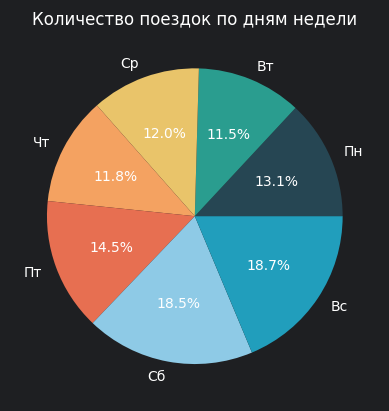

In [68]:
values = list(num.values())
colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51', '#8ECAE6', '#219EBC']
plt.pie(values, labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], autopct='%1.1f%%', colors=colors)
plt.title('Количество поездок по дням недели')
plt.show() 
# по графику можно сказать будто в выходные спрос выше(сб:18,5; вс:18,7) затем по спросу пт(14,5) пн(13,1) ср(12) чт(11,8) вт(11,5)

### Статистически

In [69]:
daily_data = pd.DataFrame({
    'date': df_r['start_date'].dt.date,
    'weekday': df_r['start_date'].dt.weekday
})

daily_rides = daily_data.groupby(['date', 'weekday']).size().reset_index(name='ride_count')

day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
daily_rides['weekday_name'] = daily_rides['weekday'].map(day_names)

def analyze_demand_by_day(daily_rides):
    groups = []
    day_labels = []

    for day in range(7):
        day_data = daily_rides[daily_rides['weekday'] == day]['ride_count']

        groups.append(day_data)
        day_labels.append(day)
        print(f"День {day} ({day_names[day]}): {len(day_data)} дней, среднее = {day_data.mean():.1f} поездок в день")
        
    h_stat, p_value = kruskal(*groups)

    print(f"\np-value = {p_value:.5f}")
    if p_value < 0.05:
        print("Статистически значимые различия между днями недели обнаружены")
    else:
        print("Статистически значимых различий между днями недели нет")

analyze_demand_by_day(daily_rides)

День 0 (Пн): 15 дней, среднее = 886.3 поездок в день
День 1 (Вт): 14 дней, среднее = 833.9 поездок в день
День 2 (Ср): 14 дней, среднее = 868.6 поездок в день
День 3 (Чт): 14 дней, среднее = 860.3 поездок в день
День 4 (Пт): 14 дней, среднее = 1053.0 поездок в день
День 5 (Сб): 15 дней, среднее = 1251.3 поездок в день
День 6 (Вс): 15 дней, среднее = 1266.1 поездок в день

p-value = 0.00000
Статистически значимые различия между днями недели обнаружены


## Выходные поездки длиннее?

In [70]:
daily_data['duration'] = df_r['end_date'] - df_r['start_date']
daily_data['date'] = pd.to_datetime(daily_data['date'])

In [71]:
daily_data.info()

<class 'pandas.DataFrame'>
Index: 101676 entries, 0 to 102254
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype          
---  ------    --------------   -----          
 0   date      101676 non-null  datetime64[s]  
 1   weekday   101676 non-null  int32          
 2   duration  101676 non-null  timedelta64[us]
dtypes: datetime64[s](1), int32(1), timedelta64[us](1)
memory usage: 6.7 MB


In [72]:
def compare_duration(data):
    weekdays = data.loc[ # Будние дни
        data['weekday'].isin([0, 1, 2, 3, 4])
    ].copy()
    weekends = data.loc[ # Выходные дни
        data['weekday'].isin([5, 6])
    ].copy()

    weekdays['duration_minutes'] = weekdays['duration'].dt.total_seconds() / 60
    weekends['duration_minutes'] = weekends['duration'].dt.total_seconds() / 60

    norm_1 = normaltest(weekdays['duration_minutes'])
    norm_2 = normaltest(weekends['duration_minutes'])

    if norm_1.pvalue > 0.05 and norm_2.pvalue > 0.05:
        stat = ttest_ind(weekdays['duration_minutes'], weekends['duration_minutes'])
        print('ttest_ind', f'H1, {stat.pvalue:.4f}'if stat.pvalue < 0.05 else f'H0, {stat.pvalue:.4f}')
    else:
        stat = mannwhitneyu(weekdays['duration_minutes'], weekends['duration_minutes'])
        print('mannwhitneyu', f'H1, {stat.pvalue}'if stat.pvalue < 0.05 else f'H0, {stat.pvalue}')

compare_duration(daily_data) # p-value очень маленькое, следовательно: H1 - различия СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ!

mannwhitneyu H1, 1.3143939462485257e-195


## В будние поездки скоростнее

In [73]:
# что бы определить нам нужно определить скорость клиентов в будние и в выходные 

In [74]:
daily_rides['speed'] = df_r['speed']

In [75]:
def compare_speed_weekdays(df):
    weekday =  df['weekday'].isin([0, 1, 2, 3, 4])
    weekend = df['weekday'].isin([5, 6])

    stat_1, p_1 = normaltest(weekday)
    stat_2, p_2 = normaltest(weekend)

    if p_1 > 0.05 and p_2 > 0.05:
        stat, p = ttest_ind(weekday, weekend)
        method = 'ttest_ind'
    else:
        stat, p = mannwhitneyu(weekday, weekend)
        method = 'mannwhitneyu'

    print(f'{method}, стат.данные: {stat}, p-value: {p}')
    print('H1' if {round(p, 4) < 0.05} else 'H0')

compare_speed_weekdays(daily_rides)
# Получается что, мы отвергаем H0 и принимаем H1, различия СТАТИСТИЧЕСКИ ЗНАЧИМЫЕ!

mannwhitneyu, стат.данные: 7171.0, p-value: 8.725349738459153e-09
H1
